In [1]:
%pip install uproot
%pip install awkward_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 46.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import uproot
import os

import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [5]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())

branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
]

df = tree.arrays(branches, library="pd")
df.head()

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


,RunID,EventID,GammaIndex,NGammas,X_mm,Y_mm,Z_mm,EnergyDeposit_keV,PreEnergy_keV,PostEnergy_keV,AnnihilX_mm,AnnihilY_mm,AnnihilZ_mm
0,slurm_36283167_1,43,0,3,22.533781,45.725643,-6.039716,187.380234,187.380234,0.0,3.079860,6.565360,-6.969770
1,slurm_36283167_1,43,1,3,-19.154974,-41.295967,42.954437,471.598907,471.598907,0.0,3.079860,6.565360,-6.969770
2,slurm_36283167_1,43,2,3,10.009033,22.802109,-44.240387,363.018677,363.018677,0.0,3.079860,6.565360,-6.969770
3,slurm_36283167_1,56,0,3,15.187184,14.526692,46.622974,492.708618,492.708618,0.0,-0.369778,0.324251,-4.727468
4,slurm_36283167_1,56,1,3,1.183054,-10.753192,-51.622868,304.623718,304.623718,0.0,-0.369778,0.324251,-4.727468


In [6]:
N_EVENTS = 15000

events = df[["RunID", "EventID"]].drop_duplicates()
events_subset = events.head(N_EVENTS)

df_subset = df.merge(events_subset, on=["RunID", "EventID"], how="inner")

print("Events selected:", len(events_subset))
print("Rows selected:  ", len(df_subset))
print("Events in subset:", df_subset.groupby(["RunID", "EventID"]).ngroups)

Events selected: 15000
Rows selected:   45000
Events in subset: 15000


In [7]:
#new equation
def build_event_arrays_2d(df_events):

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(
        ["RunID", "EventID"]
    ):

        # Order hits by decreasing energy, not GammaIndex — GammaIndex is a
        # Geant4 bookkeeping label with no physical meaning.
        event = event.sort_values(
            ["EnergyDeposit_keV", "GammaIndex"],
            ascending=[False, True]
        ).reset_index(drop=True)

        if len(event) < 3:
            continue

        event = event.iloc[:3]

        hit1 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[0].values.astype(float)

        hit2 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[1].values.astype(float)

        hit3 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[2].values.astype(float)

        v1 = hit2 - hit1
        v2 = hit3 - hit1

        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            continue

        normal = normal / normal_length

        basis_u = v1 / (
            np.linalg.norm(v1) + 1e-8
        )

        basis_v = np.cross(normal, basis_u)

        basis_v = basis_v / (
            np.linalg.norm(basis_v) + 1e-8
        )

        plane_data = np.concatenate([
            hit1,
            normal,
            basis_u,
            basis_v
        ])

        plane_list.append(plane_data)

        energy1 = float(
            event.iloc[0]["EnergyDeposit_keV"]
        )

        energy2 = float(
            event.iloc[1]["EnergyDeposit_keV"]
        )

        energy3 = float(
            event.iloc[2]["EnergyDeposit_keV"]
        )

        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        def gamma_opening_angle(e_i, e_j, e_k):
            # Physical emission angle between photons i and j, from
            # energy/momentum conservation (Fujimoto et al. 2026, Eq. 4):
            # https://doi.org/10.1038/s42005-026-02782-6
            cos_theta = (-e_i**2 - e_j**2 + e_k**2) / (2 * e_i * e_j + 1e-8)
            return np.arccos(np.clip(cos_theta, -1.0, 1.0))

        angle1 = gamma_opening_angle(energy1, energy2, energy3)  # θ between γ1, γ2
        angle2 = gamma_opening_angle(energy2, energy3, energy1)  # θ between γ2, γ3
        angle3 = gamma_opening_angle(energy3, energy1, energy2)  # θ between γ3, γ1

        features = np.concatenate([
            hit1, [energy1],
            hit2, [energy2],
            hit3, [energy3],
            [d12, d13, d23],
            [angle1, angle2, angle3]
        ])

        features_list.append(features)

        target = event[
            [
                "AnnihilX_mm",
                "AnnihilY_mm",
                "AnnihilZ_mm"
            ]
        ].iloc[0].values.astype(float)

        targets_list.append(target)

    return (
        np.array(features_list),
        np.array(targets_list),
        np.array(plane_list)
    )


X_plane2d, y_plane2d, plane_data_plane2d = build_event_arrays_2d(
    df_subset
)

print("X_plane2d shape:", X_plane2d.shape)
print("y_plane2d shape:", y_plane2d.shape)
print("plane_data_plane2d shape:", plane_data_plane2d.shape)

X_plane2d shape: (15000, 18)
y_plane2d shape: (15000, 3)
plane_data_plane2d shape: (15000, 12)


In [8]:
X_train_plane2d, X_temp_plane2d, \
y_train_plane2d, y_temp_plane2d, \
plane_train_plane2d, plane_temp_plane2d = train_test_split(
    X_plane2d,
    y_plane2d,
    plane_data_plane2d,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_val_plane2d, X_test_plane2d, \
y_val_plane2d, y_test_plane2d, \
plane_val_plane2d, plane_test_plane2d = train_test_split(
    X_temp_plane2d,
    y_temp_plane2d,
    plane_temp_plane2d,
    test_size=0.33,
    random_state=RANDOM_STATE
)

print("Training:", X_train_plane2d.shape)
print("Validation:", X_val_plane2d.shape)
print("Test:", X_test_plane2d.shape)

Training: (12000, 18)
Validation: (2010, 18)
Test: (990, 18)


In [9]:
input_scaler_plane2d = StandardScaler()

X_train_scaled_plane2d = input_scaler_plane2d.fit_transform(
    X_train_plane2d
)

X_val_scaled_plane2d = input_scaler_plane2d.transform(
    X_val_plane2d
)

X_test_scaled_plane2d = input_scaler_plane2d.transform(
    X_test_plane2d
)

In [25]:
def xyz_to_uv_plane2d(y_xyz, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    displacement = y_xyz - plane_point

    u = np.sum(
        displacement * basis_u,
        axis=1
    )

    v = np.sum(
        displacement * basis_v,
        axis=1
    )

    return np.column_stack([u, v])


y_train_uv_plane2d = xyz_to_uv_plane2d(
    y_train_plane2d,
    plane_train_plane2d
)

y_val_uv_plane2d = xyz_to_uv_plane2d(
    y_val_plane2d,
    plane_val_plane2d
)

y_test_uv_plane2d = xyz_to_uv_plane2d(
    y_test_plane2d,
    plane_test_plane2d
)

print("Training UV:", y_train_uv_plane2d.shape)
print("Validation UV:", y_val_uv_plane2d.shape)
print("Test UV:", y_test_uv_plane2d.shape)

Training UV: (12000, 2)
Validation UV: (2010, 2)
Test UV: (990, 2)


In [39]:
from sklearn.preprocessing import StandardScaler

uv_scaler = StandardScaler()

y_train_uv_scaled = uv_scaler.fit_transform(
    y_train_uv_plane2d
)

y_val_uv_scaled = uv_scaler.transform(
    y_val_uv_plane2d
)

In [26]:
class VAEPlane2D(tf.keras.Model):

    def __init__(self, hidden_units=128, latent_dim=8):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder_dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.encoder_dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.encoder_dense3 = tf.keras.layers.Dense(
            64,
            activation="relu"
        )

        # Latent distribution
        self.z_mean = tf.keras.layers.Dense(latent_dim)
        self.z_log_var = tf.keras.layers.Dense(latent_dim)

        # Decoder
        self.decoder_dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.decoder_dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.decoder_dense3 = tf.keras.layers.Dense(
            64,
            activation="relu"
        )

        # Output u,v
        self.output_layer = tf.keras.layers.Dense(2)

    def sample(self, z_mean, z_log_var):

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var) * epsilon
        )

    def call(self, x, training=False):

        # Encoder
        x = self.encoder_dense1(x)
        x = self.encoder_dense2(x)
        x = self.encoder_dense3(x)

        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)

        # Sample only during training
        if training:
            z = self.sample(
                z_mean,
                z_log_var
            )
        else:
            z = z_mean

        # Decoder
        x = self.decoder_dense1(z)
        x = self.decoder_dense2(x)
        x = self.decoder_dense3(x)

        output = self.output_layer(x)

        return output, z_mean, z_log_var

In [27]:
vae_plane2d = VAEPlane2D(
    hidden_units=128,
    latent_dim=8
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

In [40]:
train_losses = []
val_losses = []

beta_max = 0.001

for epoch in range(200):

    # Gradually increase KL weight
    beta = beta_max * min(epoch / 30, 1.0)

    # Training
    with tf.GradientTape() as tape:

        y_pred, z_mean, z_log_var = vae_plane2d(
            X_train_scaled_plane2d,
            training=True
        )

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.square(
                y_train_uv_plane2d - y_pred
            )
        )

        # KL loss
        kl_loss = -0.5 * tf.reduce_mean(
            1
            + z_log_var
            - tf.square(z_mean)
            - tf.exp(z_log_var)
        )

        # Total loss
        total_loss = (
            reconstruction_loss
            + beta * kl_loss
        )

    gradients = tape.gradient(
        total_loss,
        vae_plane2d.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            vae_plane2d.trainable_variables
        )
    )

    # Validation
    y_val_pred, z_mean_val, z_log_var_val = vae_plane2d(
        X_val_scaled_plane2d,
        training=False
    )

    val_reconstruction_loss = tf.reduce_mean(
        tf.square(
            y_val_uv_plane2d - y_val_pred
        )
    )

    val_kl_loss = -0.5 * tf.reduce_mean(
        1
        + z_log_var_val
        - tf.square(z_mean_val)
        - tf.exp(z_log_var_val)
    )

    val_total_loss = (
        val_reconstruction_loss
        + beta * val_kl_loss
    )

    train_losses.append(float(total_loss))
    val_losses.append(float(val_total_loss))

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/100 - "
            f"beta: {beta:.5f} - "
            f"loss: {total_loss:.4f} - "
            f"val_loss: {val_total_loss:.4f}"
        )

Epoch 10/100 - beta: 0.00030 - loss: 25.8125 - val_loss: 32.7917
Epoch 20/100 - beta: 0.00063 - loss: 24.3247 - val_loss: 23.0337
Epoch 30/100 - beta: 0.00097 - loss: 20.2567 - val_loss: 18.0004
Epoch 40/100 - beta: 0.00100 - loss: 10.2594 - val_loss: 8.4277
Epoch 50/100 - beta: 0.00100 - loss: 5.6647 - val_loss: 4.9105
Epoch 60/100 - beta: 0.00100 - loss: 3.6243 - val_loss: 3.3581
Epoch 70/100 - beta: 0.00100 - loss: 2.7710 - val_loss: 2.6492
Epoch 80/100 - beta: 0.00100 - loss: 2.2344 - val_loss: 2.1672
Epoch 90/100 - beta: 0.00100 - loss: 1.8779 - val_loss: 1.8642
Epoch 100/100 - beta: 0.00100 - loss: 1.6365 - val_loss: 1.6567
Epoch 110/100 - beta: 0.00100 - loss: 1.4706 - val_loss: 1.5129
Epoch 120/100 - beta: 0.00100 - loss: 1.3313 - val_loss: 1.4069
Epoch 130/100 - beta: 0.00100 - loss: 1.2406 - val_loss: 1.3159
Epoch 140/100 - beta: 0.00100 - loss: 1.1511 - val_loss: 1.2360
Epoch 150/100 - beta: 0.00100 - loss: 1.0684 - val_loss: 1.1765
Epoch 160/100 - beta: 0.00100 - loss: 1.00

In [41]:
def uv_to_xyz_plane2d(uv, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    u = uv[:, 0]
    v = uv[:, 1]

    xyz = (
        plane_point
        + u[:, None] * basis_u
        + v[:, None] * basis_v
    )

    return xyz

In [42]:
uv_pred_plane2d, z_mean_test, z_log_var_test = vae_plane2d(
    X_test_scaled_plane2d,
    training=False
)

uv_pred_plane2d = uv_pred_plane2d.numpy()

xyz_pred_plane2d = uv_to_xyz_plane2d(
    uv_pred_plane2d,
    plane_test_plane2d
)

print("UV prediction shape:", uv_pred_plane2d.shape)
print("XYZ prediction shape:", xyz_pred_plane2d.shape)

UV prediction shape: (990, 2)
XYZ prediction shape: (990, 3)


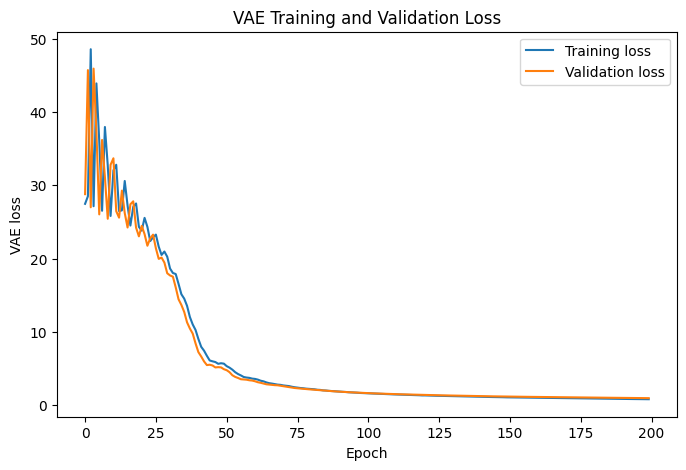

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.title("VAE Training and Validation Loss")

plt.legend()
plt.show()

In [44]:
from sklearn.metrics import r2_score
errors_plane2d = (
    xyz_pred_plane2d - y_test_plane2d
)

absolute_errors_plane2d = np.abs(
    errors_plane2d
)

x_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 0]
)

y_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 1]
)

z_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 2]
)

print("X MAE:", x_mae_plane2d, "mm")
print("Y MAE:", y_mae_plane2d, "mm")
print("Z MAE:", z_mae_plane2d, "mm")

X MAE: 0.5302165913773077 mm
Y MAE: 0.5137240103344948 mm
Z MAE: 0.5149193693796922 mm


In [45]:
# Get VAE predictions on validation data

y_val_pred, z_mean_val, z_log_var_val = vae_plane2d(
    X_val_scaled_plane2d,
    training=False
)

y_val_pred = y_val_pred.numpy()

print("True UV mean:")
print(np.mean(y_val_uv_plane2d, axis=0))

print("\nTrue UV std:")
print(np.std(y_val_uv_plane2d, axis=0))

print("\nPredicted UV mean:")
print(np.mean(y_val_pred, axis=0))

print("\nPredicted UV std:")
print(np.std(y_val_pred, axis=0))

True UV mean:
[57.98719765 12.10348265]

True UV std:
[11.50068383  6.45916174]

Predicted UV mean:
[58.00278  12.088259]

Predicted UV std:
[11.450754   6.4472613]


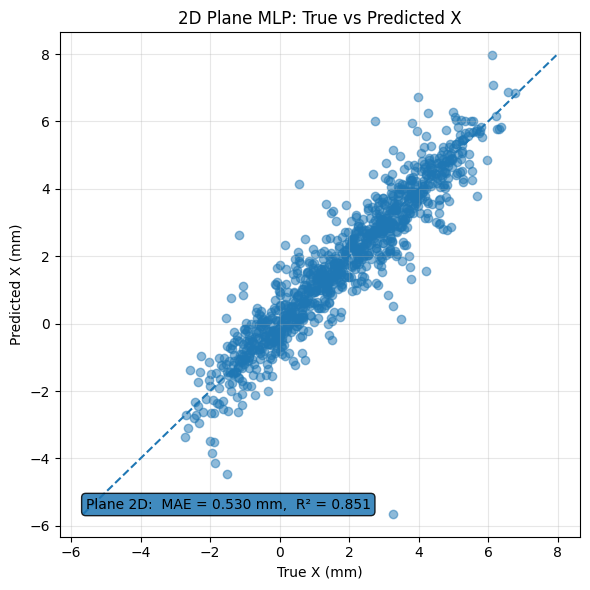

0.850920866033114


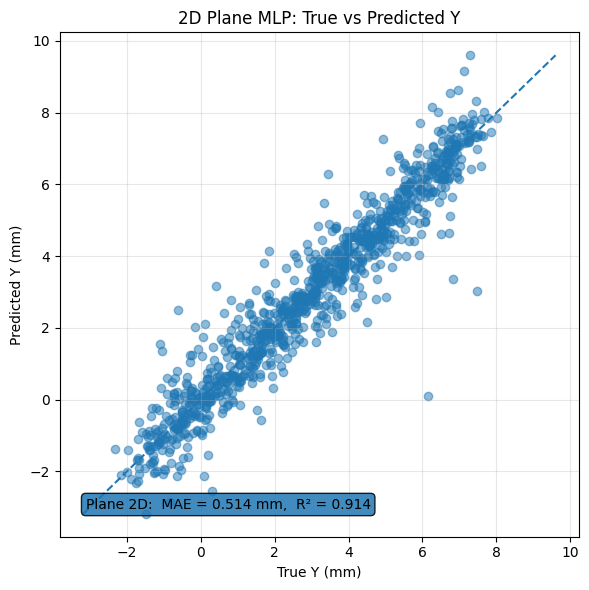

0.9143427482138697


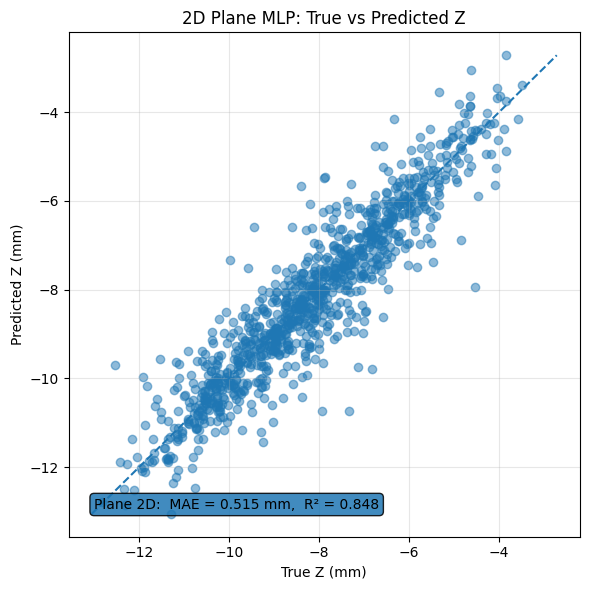

0.848098882707391


In [46]:
figures = [
    ("X", 0, x_mae_plane2d),
    ("Y", 1, y_mae_plane2d),
    ("Z", 2, z_mae_plane2d)
]

for coordinate, index, mae_val in figures:

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_plane2d[:, index],
        xyz_pred_plane2d[:, index],
        alpha=0.5
    )

    minimum = min(
        y_test_plane2d[:, index].min(),
        xyz_pred_plane2d[:, index].min()
    )

    maximum = max(
        y_test_plane2d[:, index].max(),
        xyz_pred_plane2d[:, index].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    r2_plane2d = r2_score(
        y_test_plane2d[:, index],
        xyz_pred_plane2d[:, index]
    )

    metrics_text = (
        f"Plane 2D:  MAE = {mae_val:.3f} mm,  R² = {r2_plane2d:.3f}"
    )

    plt.text(
        0.05,
        0.05,
        metrics_text,
        transform=plt.gca().transAxes,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round",
            alpha=0.85
        )
    )

    plt.xlabel(f"True {coordinate} (mm)")
    plt.ylabel(f"Predicted {coordinate} (mm)")
    plt.title(
        f"2D Plane MLP: True vs Predicted {coordinate}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print (r2_plane2d)

In [52]:
model_errors_plane2d = np.linalg.norm(
    xyz_pred_plane2d - y_test_plane2d,
    axis=1
)

mean_error_plane2d = np.mean(
    model_errors_plane2d
)

median_error_plane2d = np.median(
    model_errors_plane2d
)

std_error_plane2d = np.std(
    model_errors_plane2d
)

max_error_plane2d = np.max(
    model_errors_plane2d
)

r2_plane2d = r2_score(
    y_test_plane2d[:, 0],
    xyz_pred_plane2d[:, 0],
)

print("2D PLANE MLP PERFORMANCE")

print(f"Mean 3D error   : {mean_error_plane2d:.3f} mm")
print(f"Median 3D error : {median_error_plane2d:.3f} mm")
print(f"Std 3D error    : {std_error_plane2d:.3f} mm")
print(f"Maximum error   : {max_error_plane2d:.3f} mm")

print()

print(f"X MAE           : {x_mae_plane2d:.3f} mm")
print(f"Y MAE           : {y_mae_plane2d:.3f} mm")
print(f"Z MAE           : {z_mae_plane2d:.3f} mm")

print()


print("PLANE CONSTRAINT")

plane_points = plane_test_plane2d[:, 0:3]
plane_normals = plane_test_plane2d[:, 3:6]

plane_distances_plane2d = np.abs(
    np.sum(
        (xyz_pred_plane2d - plane_points)
        * plane_normals,
        axis=1
    )
)

print(
    f"Mean plane distance   : "
    f"{np.mean(plane_distances_plane2d):.6f} mm"
)

print(
    f"Median plane distance : "
    f"{np.median(plane_distances_plane2d):.6f} mm"
)

print(
    f"R 2 Values: "
    f"{r2_score(y_test_plane2d[:, 0], xyz_pred_plane2d[:, 0] ):.6f}  "
)
print(
    f"Maximum plane distance: "
    f"{np.max(plane_distances_plane2d):.6f} mm"
)

2D PLANE MLP PERFORMANCE
Mean 3D error   : 1.040 mm
Median 3D error : 0.840 mm
Std 3D error    : 0.777 mm
Maximum error   : 11.043 mm

X MAE           : 0.530 mm
Y MAE           : 0.514 mm
Z MAE           : 0.515 mm

PLANE CONSTRAINT
Mean plane distance   : 0.000000 mm
Median plane distance : 0.000000 mm
R 2 Values: 0.850921  
Maximum plane distance: 0.000000 mm


In [54]:
errors_3d = np.linalg.norm(
    y_test_plane2d - xyz_pred_plane2d,
    axis=1
)

print("Mean 3D error   :", np.mean(errors_3d))
print("Median 3D error :", np.median(errors_3d))
print("Std 3D error    :", np.std(errors_3d))
print("Maximum error   :", np.max(errors_3d))

Mean 3D error   : 1.0396816694443534
Median 3D error : 0.8401773371221737
Std 3D error    : 0.7772548554660035
Maximum error   : 11.043407178431924


In [55]:
mean_position_plane2d = np.mean(
    y_train_plane2d,
    axis=0
)

print(
    "Mean annihilation position (train):",
    mean_position_plane2d
)

mean_predictions_plane2d = np.tile(
    mean_position_plane2d,
    (len(y_test_plane2d), 1)
)

mean_errors_plane2d = np.linalg.norm(
    mean_predictions_plane2d - y_test_plane2d,
    axis=1
)

baseline_mean_plane2d = np.mean(
    mean_errors_plane2d
)

baseline_median_plane2d = np.median(
    mean_errors_plane2d
)

print(
    "\nMean-position baseline — mean 3D error:",
    baseline_mean_plane2d,
    "mm"
)

print(
    "Mean-position baseline — median 3D error:",
    baseline_median_plane2d,
    "mm"
)

improvement_plane2d = (
    (baseline_mean_plane2d - mean_error_plane2d)
    / baseline_mean_plane2d
    * 100
)

print(
    f"\n2D plane MLP mean 3D error: "
    f"{mean_error_plane2d:.3f} mm"
)

print(
    f"Baseline mean 3D error: "
    f"{baseline_mean_plane2d:.3f} mm"
)

print(
    f"Improvement over baseline: "
    f"{improvement_plane2d:.1f}%"
)

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error: 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

2D plane MLP mean 3D error: 1.040 mm
Baseline mean 3D error: 3.548 mm
Improvement over baseline: 70.7%


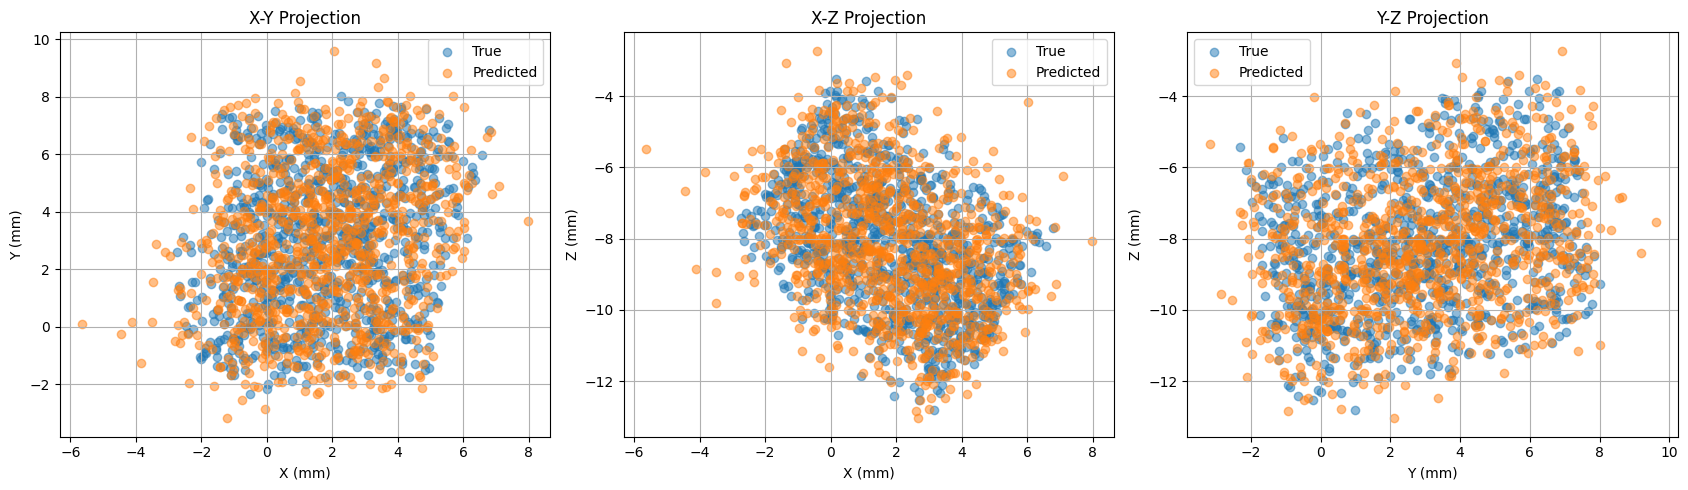

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test_plane2d[:, i], y_test_plane2d[:, j], alpha=0.5, label="True")
    ax.scatter(xyz_pred_plane2d[:, i], xyz_pred_plane2d[:, j], alpha=0.5, label="Predicted")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}-{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

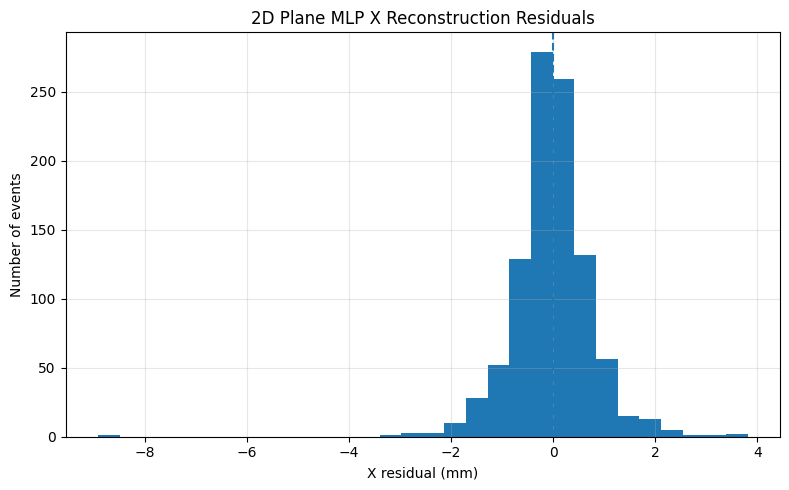

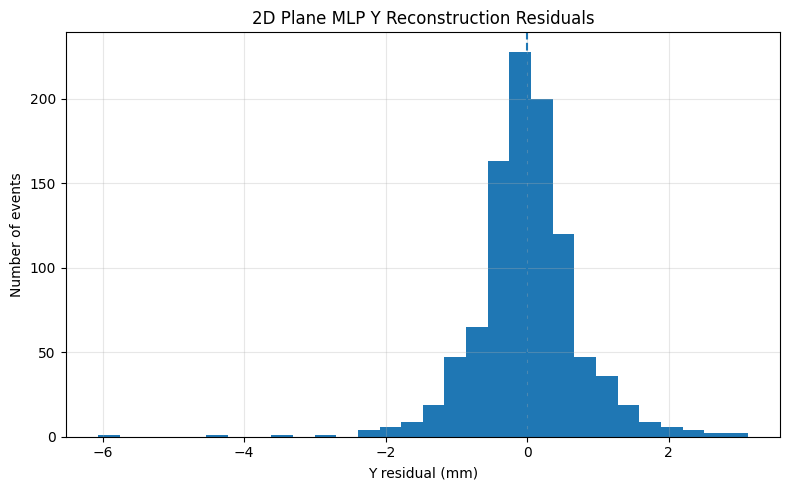

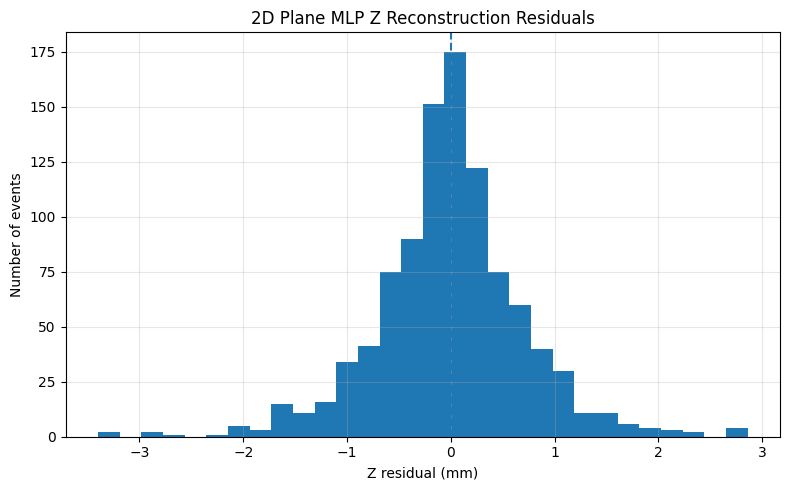

In [57]:
for coordinate, index in [
    ("X", 0),
    ("Y", 1),
    ("Z", 2)
]:

    plt.figure(figsize=(8, 5))

    plt.hist(
        errors_plane2d[:, index],
        bins=30
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(f"{coordinate} residual (mm)")
    plt.ylabel("Number of events")
    plt.title(
        f"2D Plane MLP {coordinate} Reconstruction Residuals"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

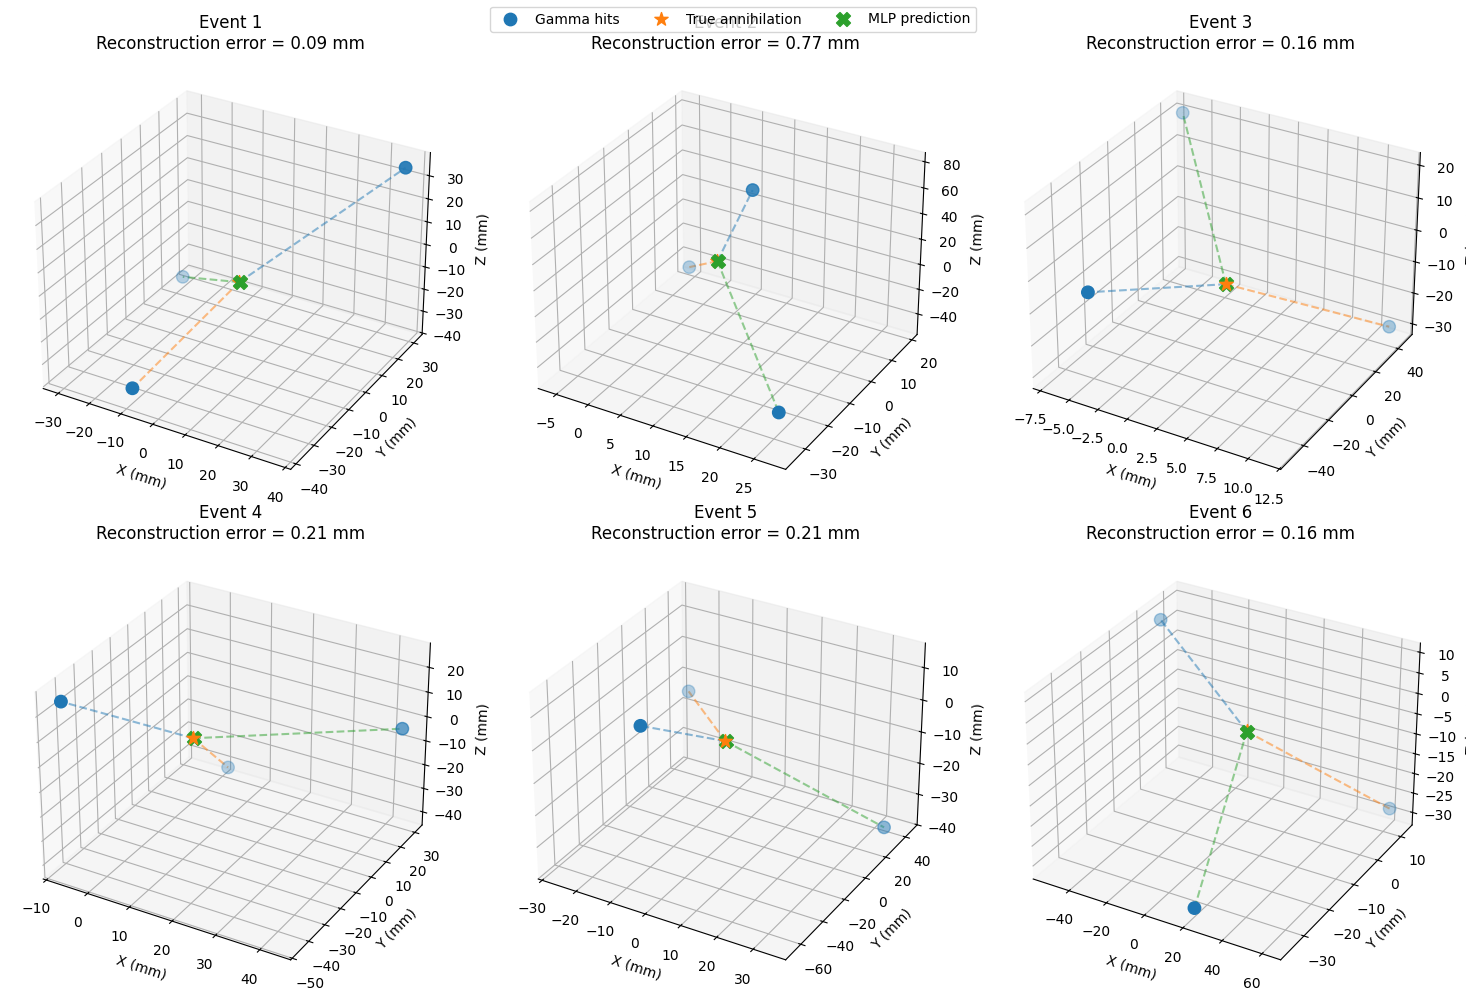

In [ ]:
n_events = min(6, len(X_test_plane2d))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    # Use X_test_plane2d for features
    hits = np.array([X_test_plane2d[i, 0:3], X_test_plane2d[i, 4:7], X_test_plane2d[i, 8:11]])
    # Use y_test_plane2d for true positions
    true_pos = y_test_plane2d[i]
    # Use xyz_pred_plane2d for predicted positions
    pred_pos = xyz_pred_plane2d[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="MLP prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i+1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

In [59]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

beta_values = [0, 0.00001, 0.0001, 0.001, 0.01]

mean_3d_errors = []
median_3d_errors = []

for beta_max in beta_values:

    print(f"\nTraining beta = {beta_max}")

    # Create a fresh model
    model = VAEPlane2D(
        hidden_units=100,
        latent_dim=2
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    for epoch in range(200):

        # KL warm-up
        beta = beta_max * min(epoch / 30, 1.0)

        with tf.GradientTape() as tape:

            y_pred, z_mean, z_log_var = model(
                X_train_scaled_plane2d,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.square(
                    y_train_uv_plane2d - y_pred
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            total_loss = (
                reconstruction_loss
                + beta * kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

    # Prediction on test data
    y_test_uv_pred, _, _ = model(
        X_test_scaled_plane2d,
        training=False
    )

    y_test_uv_pred = y_test_uv_pred.numpy()

    # Convert predicted UV coordinates back to XYZ
    y_test_xyz_pred = uv_to_xyz(
        y_test_uv_pred,
        test_planes
    )

    # Calculate 3D errors
    errors_3d = np.linalg.norm(
        y_test_xyz_pred - y_test_xyz,
        axis=1
    )

    mean_error = np.mean(errors_3d)
    median_error = np.median(errors_3d)

    mean_3d_errors.append(mean_error)
    median_3d_errors.append(median_error)

    print(
        f"Mean 3D error: {mean_error:.3f} mm"
    )

    print(
        f"Median 3D error: {median_error:.3f} mm"
    )


Training beta = 0


KeyboardInterrupt: 

In [62]:
beta_values = [0, 0.00001, 0.0001, 0.001, 0.01]

mean_3d_errors = []
median_3d_errors = []

for beta_max in beta_values:

    print(f"\nTraining beta = {beta_max}")

    model = VAEPlane2D(
        hidden_units=100,
        latent_dim=8
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    for epoch in range(200):

        beta = beta_max * min(epoch / 30, 1.0)

        with tf.GradientTape() as tape:

            y_pred, z_mean, z_log_var = model(
                X_train_scaled_plane2d,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.square(
                    y_train_uv_plane2d - y_pred
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            total_loss = (
                reconstruction_loss
                + beta * kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

    y_test_uv_pred, _, _ = model(
        X_test_scaled_plane2d,
        training=False
    )

    y_test_uv_pred = y_test_uv_pred.numpy()

    y_test_xyz_pred = uv_to_xyz_plane2d(
        y_test_uv_pred,
        plane_test_plane2d
    )

    errors_3d = np.linalg.norm(
        y_test_xyz_pred - y_test_plane2d,
        axis=1
    )

    mean_error = np.mean(errors_3d)
    median_error = np.median(errors_3d)

    mean_3d_errors.append(mean_error)
    median_3d_errors.append(median_error)

    print(f"Mean 3D error: {mean_error:.3f} mm")
    print(f"Median 3D error: {median_error:.3f} mm")


Training beta = 0
Mean 3D error: 3.396 mm
Median 3D error: 3.127 mm

Training beta = 1e-05
Mean 3D error: 4.750 mm
Median 3D error: 4.295 mm

Training beta = 0.0001
Mean 3D error: 5.745 mm
Median 3D error: 5.140 mm

Training beta = 0.001
Mean 3D error: 2.681 mm
Median 3D error: 2.368 mm

Training beta = 0.01
Mean 3D error: 2.768 mm
Median 3D error: 2.444 mm


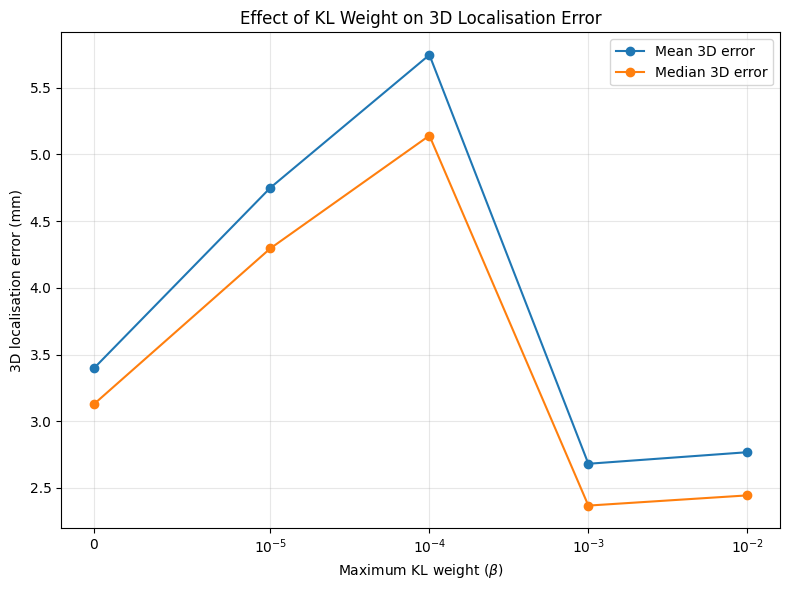

In [63]:
plt.figure(figsize=(8, 6))

plt.plot(
    beta_values,
    mean_3d_errors,
    marker="o",
    label="Mean 3D error"
)

plt.plot(
    beta_values,
    median_3d_errors,
    marker="o",
    label="Median 3D error"
)

plt.xscale("symlog", linthresh=1e-5)

plt.xlabel(r"Maximum KL weight ($\beta$)")
plt.ylabel("3D localisation error (mm)")
plt.title("Effect of KL Weight on 3D Localisation Error")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
tf.keras.utils.set_random_seed(42)
beta_values = [0, 0.00001, 0.0001, 0.001, 0.01]

mean_3d_errors = []
median_3d_errors = []

for beta_max in beta_values:

    print(f"\nTraining beta = {beta_max}")

    model = VAEPlane2D(
        hidden_units=100,
        latent_dim=8
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    for epoch in range(200):

        beta = beta_max * min(epoch / 30, 1.0)

        with tf.GradientTape() as tape:

            y_pred, z_mean, z_log_var = model(
                X_train_scaled_plane2d,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.square(
                    y_train_uv_plane2d - y_pred
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            total_loss = (
                reconstruction_loss
                + beta * kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

    y_test_uv_pred, _, _ = model(
        X_test_scaled_plane2d,
        training=False
    )

    y_test_uv_pred = y_test_uv_pred.numpy()

    y_test_xyz_pred = uv_to_xyz_plane2d(
        y_test_uv_pred,
        plane_test_plane2d
    )

    errors_3d = np.linalg.norm(
        y_test_xyz_pred - y_test_plane2d,
        axis=1
    )

    mean_error = np.mean(errors_3d)
    median_error = np.median(errors_3d)

    mean_3d_errors.append(mean_error)
    median_3d_errors.append(median_error)

    print(f"Mean 3D error: {mean_error:.3f} mm")
    print(f"Median 3D error: {median_error:.3f} mm")


Training beta = 0
Mean 3D error: 2.458 mm
Median 3D error: 2.168 mm

Training beta = 1e-05
Mean 3D error: 5.911 mm
Median 3D error: 5.354 mm

Training beta = 0.0001
Mean 3D error: 2.670 mm
Median 3D error: 2.423 mm

Training beta = 0.001
Mean 3D error: 5.930 mm
Median 3D error: 5.325 mm

Training beta = 0.01
Mean 3D error: 3.124 mm
Median 3D error: 2.854 mm


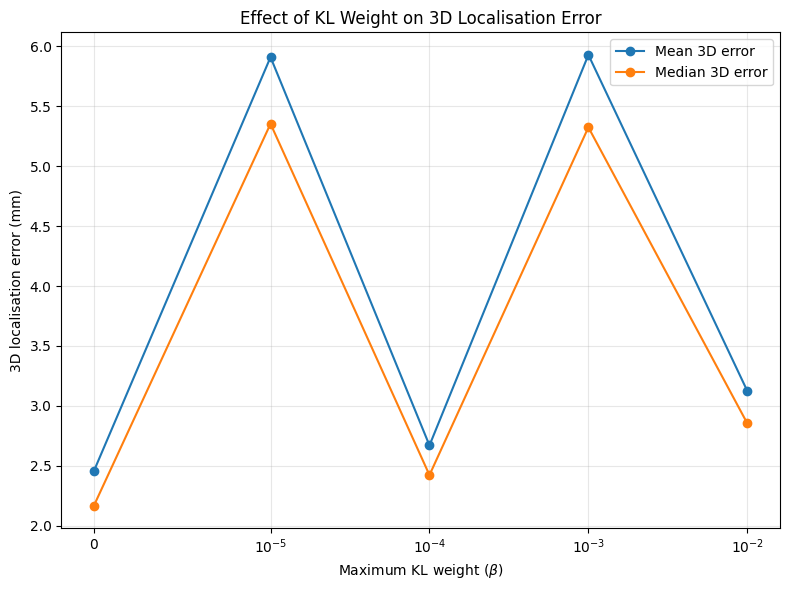

In [65]:
plt.figure(figsize=(8, 6))

plt.plot(
    beta_values,
    mean_3d_errors,
    marker="o",
    label="Mean 3D error"
)

plt.plot(
    beta_values,
    median_3d_errors,
    marker="o",
    label="Median 3D error"
)

plt.xscale("symlog", linthresh=1e-5)

plt.xlabel(r"Maximum KL weight ($\beta$)")
plt.ylabel("3D localisation error (mm)")
plt.title("Effect of KL Weight on 3D Localisation Error")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
#sweeping near 0
tf.keras.utils.set_random_seed(42)
beta_values = [
    0,
    0.000025,
    0.00005,
    0.000075,
    0.0001,
    0.00015,
    0.0002,
    0.0003
]

mean_3d_errors = []
median_3d_errors = []

for beta_max in beta_values:

    print(f"\nTraining beta = {beta_max}")

    model = VAEPlane2D(
        hidden_units=100,
        latent_dim=8
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    for epoch in range(200):

        beta = beta_max * min(epoch / 30, 1.0)

        with tf.GradientTape() as tape:

            y_pred, z_mean, z_log_var = model(
                X_train_scaled_plane2d,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.square(
                    y_train_uv_plane2d - y_pred
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            total_loss = (
                reconstruction_loss
                + beta * kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

    y_test_uv_pred, _, _ = model(
        X_test_scaled_plane2d,
        training=False
    )

    y_test_uv_pred = y_test_uv_pred.numpy()

    y_test_xyz_pred = uv_to_xyz_plane2d(
        y_test_uv_pred,
        plane_test_plane2d
    )

    errors_3d = np.linalg.norm(
        y_test_xyz_pred - y_test_plane2d,
        axis=1
    )

    mean_error = np.mean(errors_3d)
    median_error = np.median(errors_3d)

    mean_3d_errors.append(mean_error)
    median_3d_errors.append(median_error)

    print(f"Mean 3D error: {mean_error:.3f} mm")
    print(f"Median 3D error: {median_error:.3f} mm")


Training beta = 0
Mean 3D error: 2.458 mm
Median 3D error: 2.168 mm

Training beta = 2.5e-05
Mean 3D error: 5.911 mm
Median 3D error: 5.354 mm

Training beta = 5e-05
Mean 3D error: 2.671 mm
Median 3D error: 2.422 mm

Training beta = 7.5e-05
Mean 3D error: 5.930 mm
Median 3D error: 5.325 mm

Training beta = 0.0001
Mean 3D error: 3.125 mm
Median 3D error: 2.844 mm

Training beta = 0.00015
Mean 3D error: 2.448 mm
Median 3D error: 2.150 mm

Training beta = 0.0002
Mean 3D error: 2.659 mm
Median 3D error: 2.465 mm

Training beta = 0.0003
Mean 3D error: 2.408 mm
Median 3D error: 2.150 mm


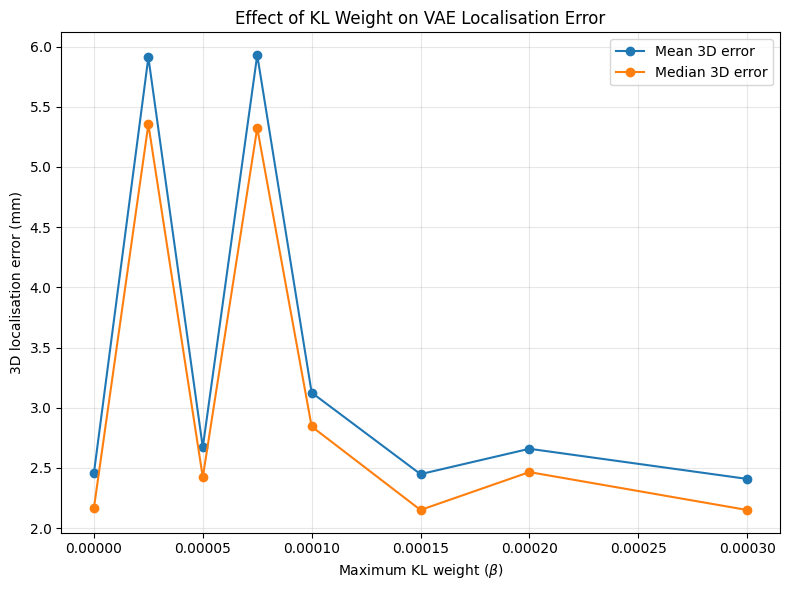

In [69]:
plt.figure(figsize=(8, 6))

plt.plot(
    beta_values,
    mean_3d_errors,
    marker="o",
    label="Mean 3D error"
)

plt.plot(
    beta_values,
    median_3d_errors,
    marker="o",
    label="Median 3D error"
)

plt.xlabel(r"Maximum KL weight ($\beta$)")
plt.ylabel("3D localisation error (mm)")
plt.title("Effect of KL Weight on VAE Localisation Error")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()